In [1]:
import json
import os
import pandas as pd
from datetime import datetime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from dateutil.parser import parse
import numpy as np
from pathlib import Path
import seaborn as sns
import math
import matplotlib.colors as mcolors
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D
import matplotlib.lines as mlines
from scipy.stats import zscore

# figure settings
new_params = {'text.usetex': False, 'svg.fonttype': 'none'}
mpl.rcParams.update(new_params)

# creating output path for figures
Path("figures").mkdir(parents=True, exist_ok=True)

### Utils

In [56]:
def load_activity_data(fileName):
    activity_data = json.load(open(fileName))['data']
    activity_df = pd.DataFrame(activity_data)
    
    return activity_df

def load_sleep_data(fileName):
    sleep_data = json.load(open(fileName))['data']
    sleep_data = [item for item in sleep_data if item['type'] == 'long_sleep']
    sleep_df = pd.DataFrame(sleep_data)
    
    sleep_df['bedtime'] = sleep_df['bedtime_start'].apply(lambda x: parse(x).strftime('%H:%M:%S'))
    sleep_df['bedtime'] = pd.to_datetime(sleep_df['bedtime'])
    sleep_df['decimal_bedtime'] = sleep_df['bedtime'].dt.hour + sleep_df['bedtime'].dt.minute / 60

    return sleep_df

def load_sync_data(fileName):
    sync_data = pd.read_csv(fileName)#, parse_dates=['timestamp_utc','timestamp_local'])
    sync_data['timestamp_utc'] = pd.to_datetime(sync_data['timestamp_utc'], utc=True)
    sync_data['timestamp_local'] = sync_data['timestamp_local'].apply(lambda x: datetime.fromisoformat(x) if pd.notna(x) else pd.NaT)
    sync_data = sync_data.set_index('timestamp_utc')
    
    return sync_data

def custom_zscore(x):
    # daily z score
    result = pd.Series(np.nan, index=x.index)
    valid = x.notna()

    if valid.any():
        result.loc[valid] = zscore(x.loc[valid])

    return result

def circular_median(angles):
    angles = np.asarray(angles)

    if len(angles) == 0:
        return np.nan

    test_angles = np.linspace(0, 2*np.pi, 1440)
    distances = np.abs(test_angles[:, None] - angles[None, :])
    distances = np.minimum(distances, 2*np.pi - distances)

    return test_angles[np.argmin(distances.sum(axis=1))]

In [5]:
# loading in activity data
ACTIVITY_DIR = r"data\activity"
p010_activity = load_activity_data(os.path.join(ACTIVITY_DIR,'P010_activity.json'))
p006_activity = load_activity_data(os.path.join(ACTIVITY_DIR,'P006_activity.json'))
p013_activity = load_activity_data(os.path.join(ACTIVITY_DIR,'P013_activity.json'))

# loading in sleep data
SLEEP_DIR = r"data\sleep"
p010_sleep = load_sleep_data(os.path.join(SLEEP_DIR,'P010_sleep.json'))
p006_sleep = load_sleep_data(os.path.join(SLEEP_DIR,'P006_sleep.json'))
p013_sleep = load_sleep_data(os.path.join(SLEEP_DIR,'P013_sleep.json'))

# loading in synced neurobehavioral data
SYNC_DIR = r"data\sync"
p010_sync = load_sync_data(os.path.join(SYNC_DIR,'P010_sync.csv'))
p006_sync = load_sync_data(os.path.join(SYNC_DIR,'P006_sync.csv'))
p013_sync = load_sync_data(os.path.join(SYNC_DIR,'P013_sync.csv'))

# defining patient IDs and colors for plots
activity_data = {'P1': p010_activity, 'P2': p006_activity, 'P3': p013_activity}
sleep_data = {'P1': p010_sleep, 'P2': p006_sleep, 'P3': p013_sleep}
sync_data = {'P1': p010_sync, 'P2': p006_sync, 'P3': p013_sync}
colors = {'P1': '#FECD91', 'P2': '#6CB9C3', 'P3': '#8BC0E8'}

C:\Users\Sai Chamarthi\AppData\Local\Temp\ipykernel_23912\555998423.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sleep_df['bedtime'] = pd.to_datetime(sleep_df['bedtime'])
C:\Users\Sai Chamarthi\AppData\Local\Temp\ipykernel_23912\555998423.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sleep_df['bedtime'] = pd.to_datetime(sleep_df['bedtime'])
C:\Users\Sai Chamarthi\AppData\Local\Temp\ipykernel_23912\555998423.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sleep_df['bedtime'] = pd.to_datetime(sleep_df['bedtime'])
C:\Users\Sai Chamarthi\AppData\Local\Temp\i

### Figure 2

#### 2a - Daily Wear Time

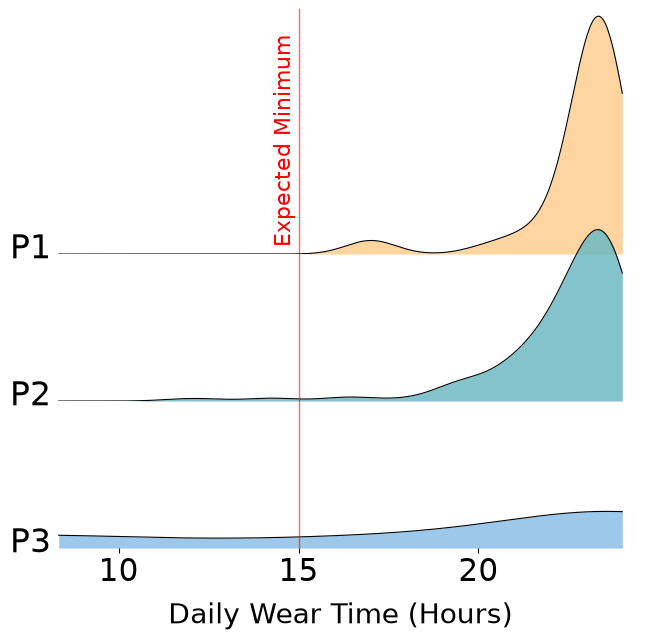

In [6]:
# non-wear time recorded in sec -> converting to wear time in hrs
wear = pd.DataFrame({
    patient: ((86400 - df['non_wear_time']) / 3600).clip(upper=24)
    for patient, df in activity_data.items()
})

fig, axes = plt.subplots(3, 1, figsize=(8, 7), sharex=True)
fig.subplots_adjust(hspace=-0.4)

# generating smooth x-grid for KDE
x = np.linspace(500 / 60, 24, 500)

densities = {}
for patient in activity_data:
    values = wear[patient].dropna().to_numpy()
    kde = gaussian_kde(values)
    densities[patient] = kde(x)

# storing highest density across all patients to standardize y axis scale
global_ymax = max(density.max() for density in densities.values())

# iterating through each patient and plotting kde
for i, (ax, patient) in enumerate(zip(axes, activity_data)):
    density = densities[patient]

    ax.fill_between(x, 0, density, color=colors[patient], alpha=0.85, linewidth=0)
    ax.plot(x, density, color='black', linewidth=0.8)

    # standardizing y axis scales
    ax.set_ylim(0, global_ymax * 1.03)
    ax.set_ylabel(patient, fontsize=24, rotation=0)
    ax.yaxis.set_label_coords(0, -0.05)
    ax.set_yticks([])

    ax.set_facecolor('none')
    for spine in ax.spines.values():
        spine.set_visible(False)

    # only show x-axis on final distribution
    if i < len(axes) - 1:
        ax.tick_params(axis='x', bottom=False, labelbottom=False)

# edits to bottom x-axis
axes[-1].set_xticks([10, 15, 20])
axes[-1].tick_params(axis='x', labelsize=22)
axes[-1].set_xlabel('Daily Wear Time (Hours)', fontsize=20, labelpad=10)

# plot vertical line to represent the minimum expected daily ring wear time (15 hrs)
x_line_disp = axes[-1].transData.transform((15, 0))[0]
x_line = fig.transFigure.inverted().transform((x_line_disp, 0))[0]

y_line_bottom = axes[-1].get_position().y0
y_line_top = axes[0].get_position().y1

line = Line2D([x_line, x_line], [y_line_bottom, y_line_top], transform=fig.transFigure, 
              color='r', linestyle='-', linewidth=1.0, alpha=0.6, zorder=10)
fig.add_artist(line)

axes[1].text(14.6, 0.5, 'Expected Minimum', fontsize=16, color='r', rotation='vertical', 
             verticalalignment='center', horizontalalignment='center')

plt.savefig('figures/figure2a.svg', format='svg', bbox_inches='tight')
plt.show()

#### 2b

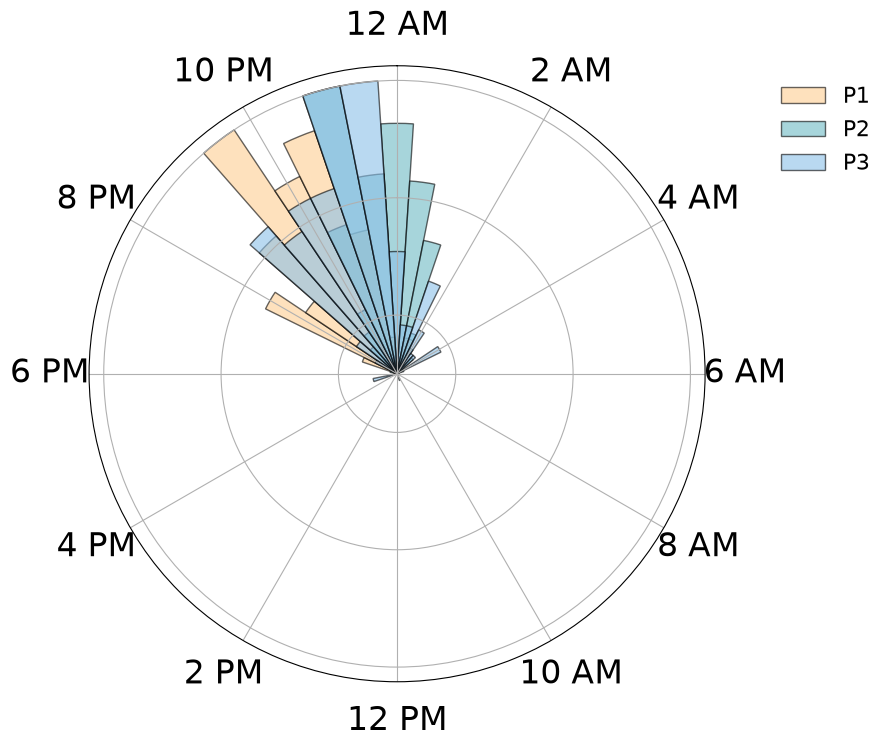

In [7]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})

# plotting histogram of bedtime start times for each patient
for patient, df in sleep_data.items():
    n, bins = np.histogram(df['decimal_bedtime'], bins=48, range=(0, 24))
    n = n / np.max(n)
    
    ax.bar(bins[:-1] * np.pi / 12, n, width=np.pi / 24, bottom=0.0,
        alpha=0.6, edgecolor='black', color=colors[patient], label=patient)

# figure adjustments
ax.set_xticks(np.linspace(0, 2*np.pi, 12, endpoint=False))
ticks = ['12 AM', '2 AM', '4 AM',  '6 AM', '8 AM','10 AM','12 PM', '2 PM', '4 PM', '6 PM',  '8 PM',  '10 PM' ]
ax.set_xticklabels(ticks, fontsize=24)
ax.tick_params(axis='x', pad=18)

yticks = ax.get_yticks()
ax.set_yticks(yticks[::2])
ax.set_yticklabels([])

# setting the theta offset and direction
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.legend(bbox_to_anchor=[1.3, 1], fontsize=16, frameon=False)
plt.savefig('figures/figure2b.svg', format='svg')
plt.show()

#### 2c

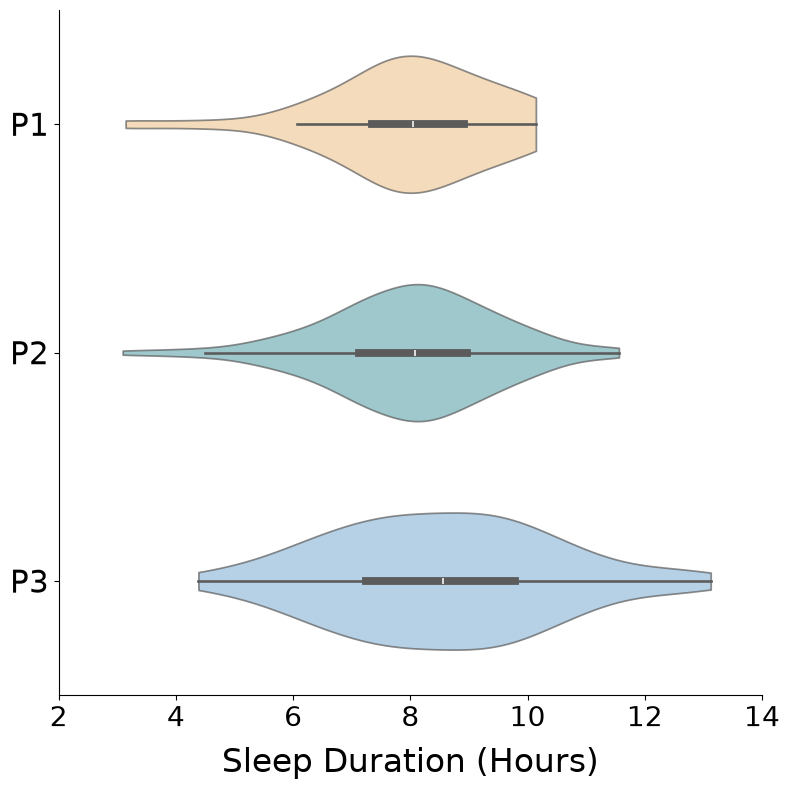

In [8]:
# extracting sleep durations for each patient
sleep_durations = [(df['total_sleep_duration'] / 3600).dropna().to_numpy() for df in sleep_data.values()]

# horizontal violin plots to visualize distribution of each patient's sleep durations
plt.figure(figsize=(8, 8))
sns.violinplot(data=sleep_durations, palette=[colors[patient] for patient in sleep_data], alpha=0.7, cut=0, orient='h', width=0.6)

plt.yticks(range(len(sleep_data)), list(sleep_data.keys()), fontsize=22)
plt.xticks(range(2, 16, 2), fontsize=20)
plt.xlabel('Sleep Duration (Hours)', fontsize=24, labelpad=10)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/figure2c.svg', format='svg')
plt.show()

#### 2d

C:\Users\Sai Chamarthi\AppData\Local\Temp\ipykernel_23912\2291475229.py:36: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


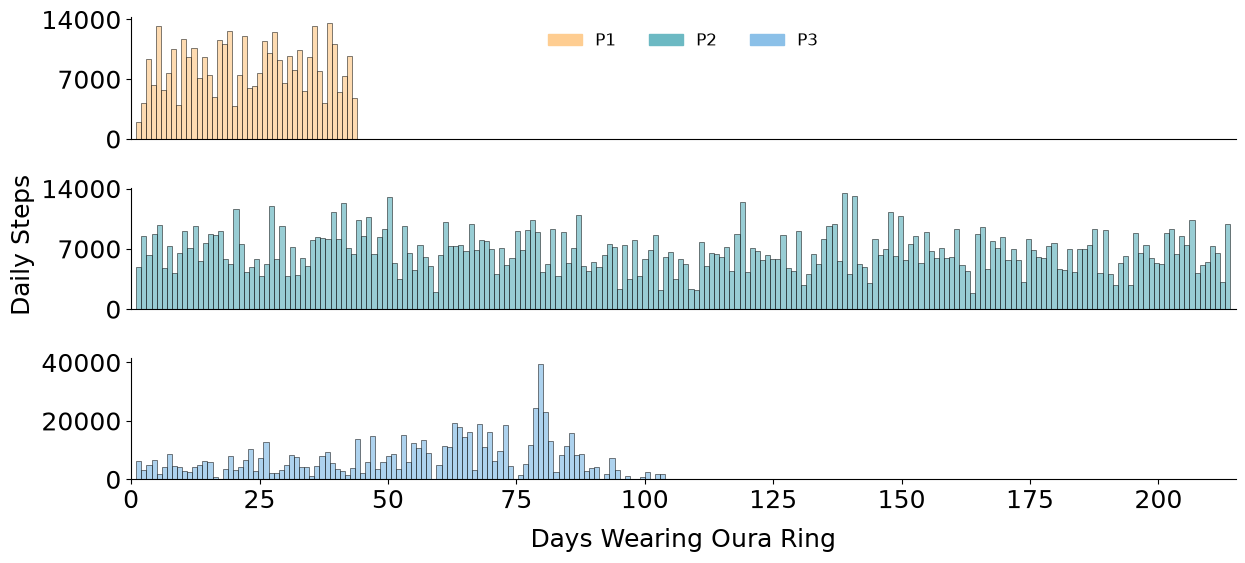

In [22]:
# extracting daily step count for each patient
steps_data = {
    patient: pd.DataFrame({'steps': df['steps'], 'day': range(1, len(df) + 1)})
    for patient, df in activity_data.items()
}

fig, axes = plt.subplots(3, 1, figsize=(14.25, 6))

max_days = max(df['day'].max() for df in steps_data.values())

# histogram of daily step count for each patient
for i, (ax, (patient, df)) in enumerate(zip(axes, steps_data.items())):
    ax.hist(df['day'], weights=df['steps'], bins=len(df), color=colors[patient], alpha=0.7, edgecolor='black', linewidth=0.5)

    min_val = 0
    max_val = math.ceil(df['steps'].max() / 1000) * 1000
    mid_val = (max_val - min_val) / 2
    ax.set_yticks([min_val, mid_val, max_val])

    if i == len(axes) - 1:
        ax.set_xlabel('Days Wearing Oura Ring', fontsize=18, labelpad=10)
    else:
        ax.set_xticks([])

    ax.tick_params(axis='both', labelsize=18)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0, max_days + 1)

fig.text(0.04, 0.5, 'Daily Steps', va='center', rotation='vertical', fontsize=18)

handles = [mpatches.Patch(color=colors[patient], label=patient) for patient in activity_data]
plt.legend(handles=handles, fontsize=12, frameon=False, ncol=3, loc='upper center', bbox_to_anchor=(0.5, 3.8))

fig.subplots_adjust(hspace=0.4)
plt.tight_layout()
plt.savefig('figures/figure2d.svg', format='svg')
plt.show()

#### 2e

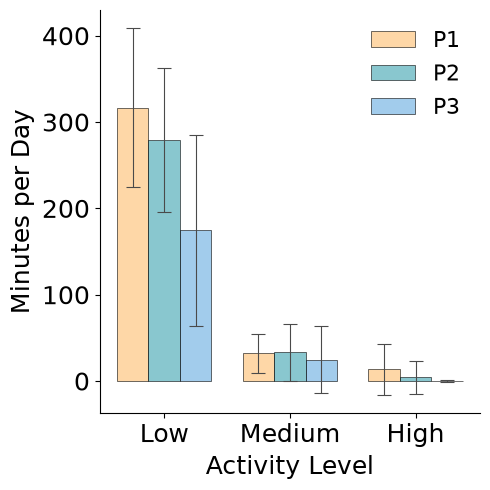

In [32]:
active_categories = ['low_activity_time', 'medium_activity_time', 'high_activity_time']
activity_labels = ['Low', 'Medium', 'High']

x_pos = np.arange(len(active_categories))
width = 0.25

fig, ax = plt.subplots(figsize=(5, 5))

for i, (patient, activity) in enumerate(activity_data.items()):
    means = [activity[category].mean() / 60 for category in active_categories]
    stds = [activity[category].std() / 60 for category in active_categories]

    ax.bar(x_pos + i * width, means, width, yerr=stds, capsize=5, error_kw={'lw': 0.8, 'capthick': 0.8},
           alpha=0.8, label=patient, color=colors[patient], ecolor='#4a4a4a', edgecolor='black', linewidth=0.5)

ax.set_xlabel('Activity Level', fontsize=18, labelpad=5)
ax.set_ylabel('Minutes per Day', fontsize=18, labelpad=5)

ax.set_xticks(x_pos + width)
ax.set_xticklabels(activity_labels, fontsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(frameon=False, fontsize=16)

plt.tight_layout()
plt.savefig('figures/figure2e.svg', format='svg')
plt.show()

#### 2f

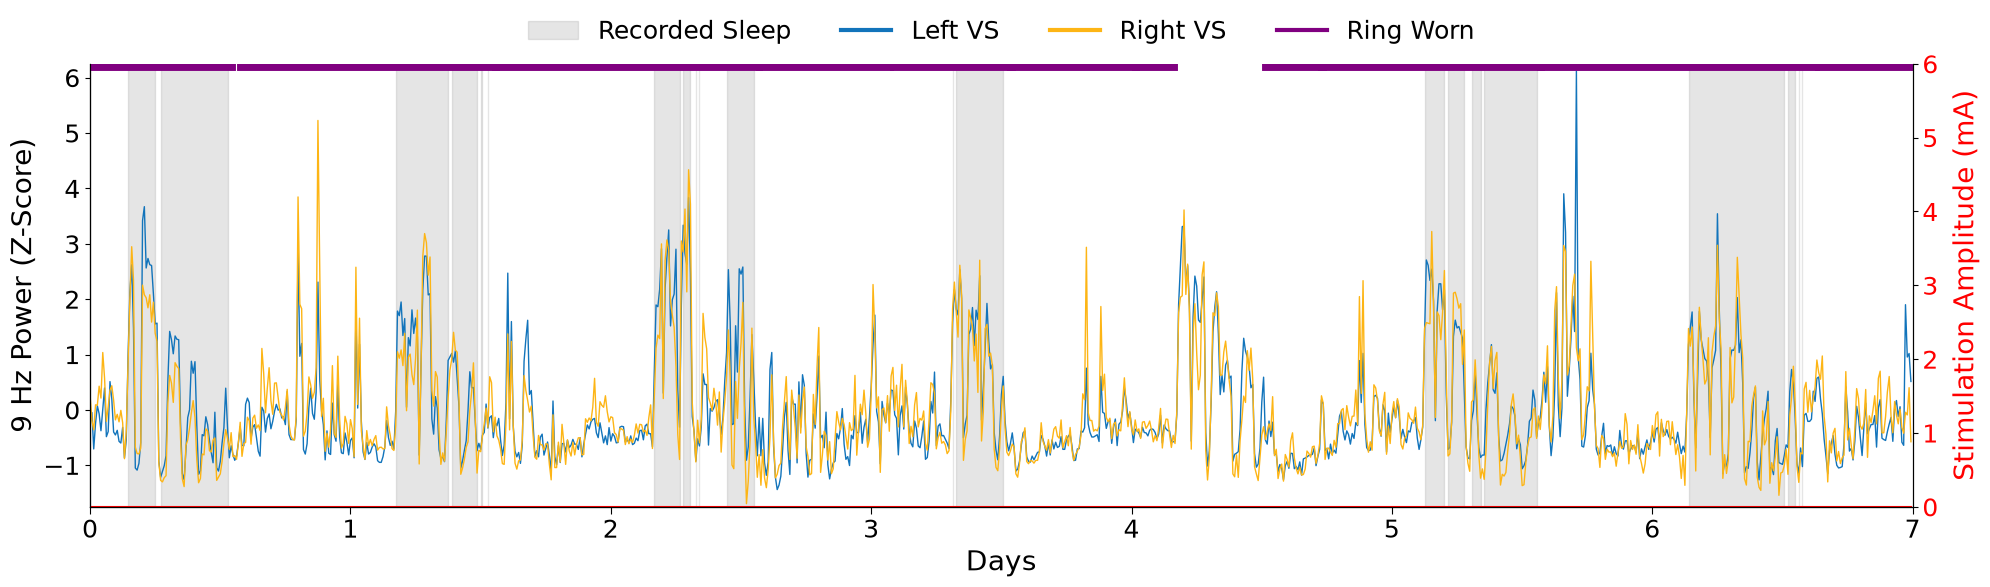

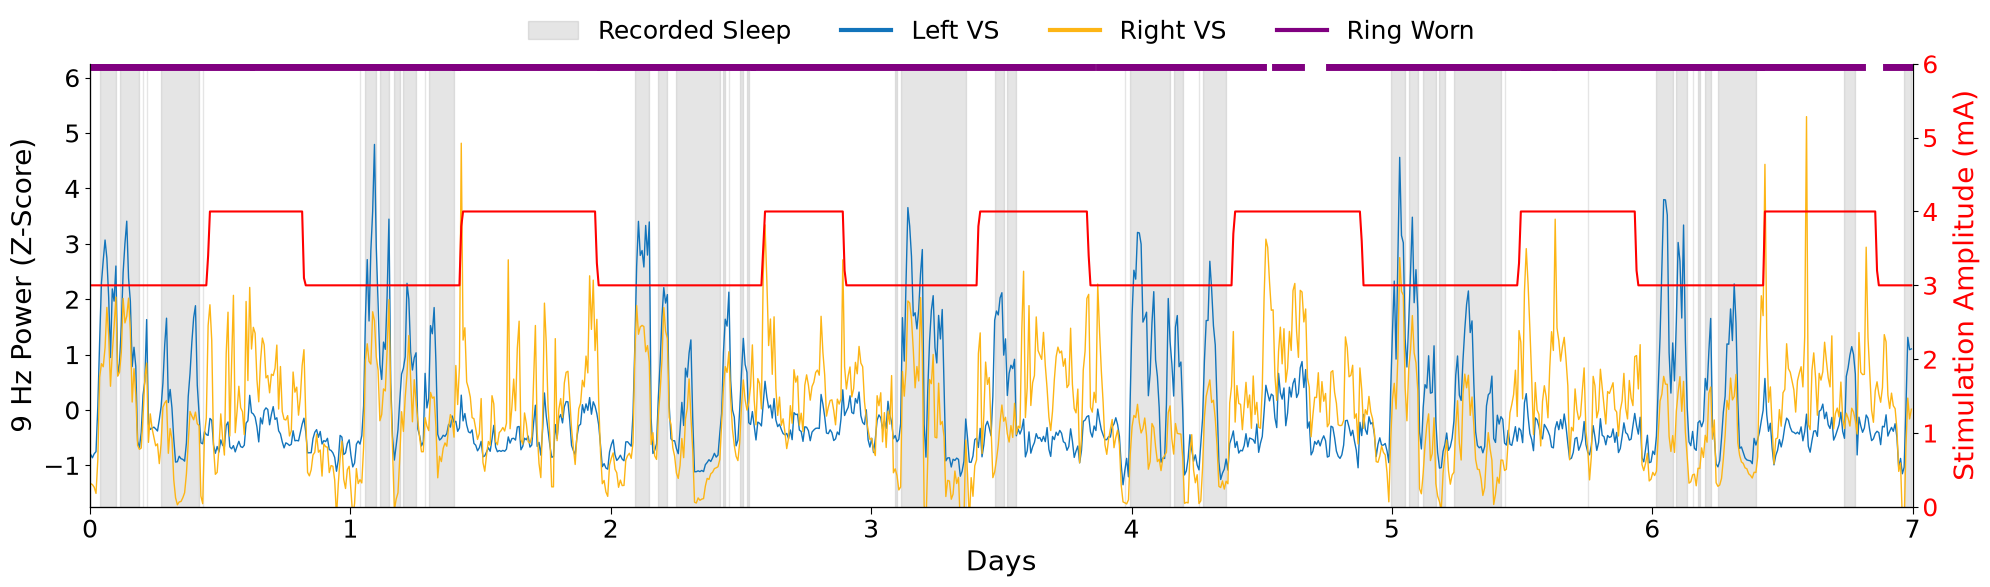

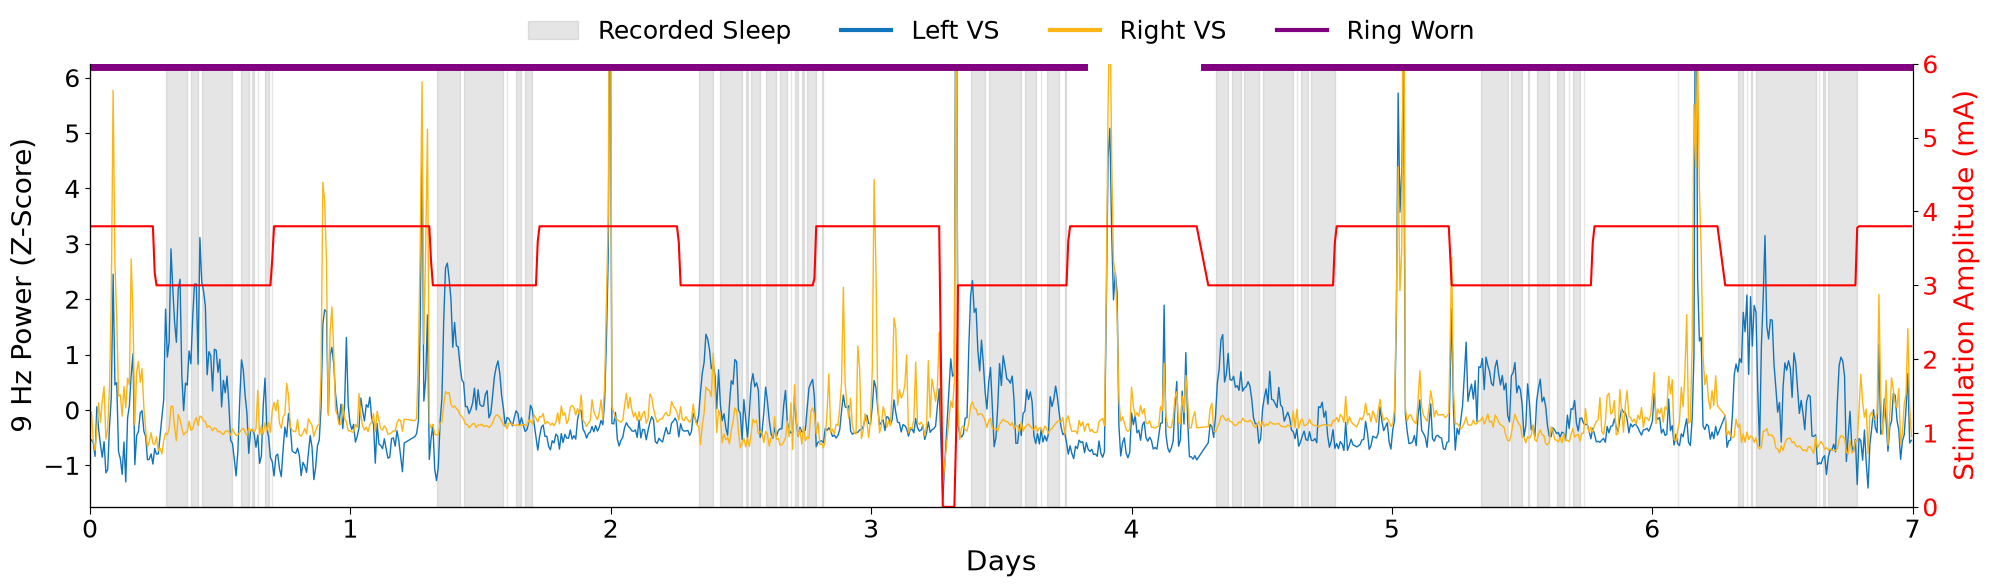

In [59]:
# defining which time period to plot for each patient (start_time + 7 days)
start_times = {
    'P1': '2023-11-26 19:00:00-06:00', 
    'P2': '2023-10-11 01:03:59-04:00', 
    'P3': '2024-04-24 22:46:35+00:00'
    }

for participant, sync_original in sync_data.items():
    sync = sync_original.copy()

    # normalizing LFP values within each local calendar day
    sync['Date'] = sync['timestamp_local'].apply(lambda x: x.date() if pd.notna(x) else pd.NaT)
    sync['Left_LFP_Zscore'] = sync.groupby('Date')['Chronic_LFP_Left'].transform(custom_zscore)
    sync['Right_LFP_Zscore'] = sync.groupby('Date')['Chronic_LFP_Right'].transform(custom_zscore)

    start_time = pd.Timestamp(start_times[participant])
    end_time = start_time + pd.Timedelta(days=7)

    data = sync.loc[start_time:end_time].copy()
    ring_worn = np.where(data['ring_worn'].fillna(False).astype(bool), 7, np.nan)

    # plotting z-scored left & right hemi LFP values
    fig, ax = plt.subplots(figsize=(20, 6))
    ax.plot(data.index, data['Left_LFP_Zscore'], color='#1274BB', linewidth=1)
    ax.plot(data.index, data['Right_LFP_Zscore'], color='#FDB515', linewidth=1)
    ax.set_ylim(-1.75, 6.25)

    # plotting stimulation amplitude
    ax2 = ax.twinx()
    ax2.plot(data.index, data['Stimulation_Left'], color='red', linewidth=1.5)
    ax2.set_ylim(0, 6)
    ax2.set_ylabel('Stimulation Amplitude (mA)', color='red', fontsize=20, labelpad=10)
    ax2.tick_params(axis='y', labelcolor='red', labelsize=18)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(True)

    # plotting whether the Oura Ring was worn or not
    ax3 = ax.twinx()
    ax3.plot(data.index, ring_worn, color='purple', linewidth=10)
    ax3.set_ylim(0, 7)
    ax3.get_yaxis().set_visible(False)
    ax3.spines['top'].set_visible(False)

    # shading in sleep periods, defined by the Oura Ring
    is_sleep = data['sleep_phase'].notna() & data['sleep_phase'].isin([1, 2, 3])
    sleep_groups = is_sleep.ne(is_sleep.shift()).cumsum()

    for _, period in data.groupby(sleep_groups):
        first_index = period.index[0]

        if is_sleep.loc[first_index]:
            ax.axvspan(period.index[0], period.index[-1], color='grey', alpha=0.2)

    ax.set_xlim(start_time, end_time)
    ax.set_ylabel('9 Hz Power (Z-Score)', fontsize=20)
    ax.set_xlabel('Days', fontsize=20)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.tick_params(axis='y', labelsize=18)
    ax.tick_params(axis='x', labelsize=18, length=5)

    date_range = pd.date_range(start=start_time, end=end_time, freq='D')
    ax.set_xticks(date_range)
    ax.set_xticklabels(range(len(date_range)))

    sleep_patch = mpatches.Patch(color='grey', alpha=0.2, label='Recorded Sleep')
    left_hemisphere = mlines.Line2D([], [], color='#1274BB', label='Left VS', linewidth=3)
    right_hemisphere = mlines.Line2D([], [], color='#FDB515', label='Right VS', linewidth=3)
    ring_wearing_time = mlines.Line2D([], [], color='purple', label='Ring Worn', linewidth=3)

    ax.legend(handles=[sleep_patch, left_hemisphere, right_hemisphere, ring_wearing_time], loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=4, frameon=False, fontsize=18)

    plt.tight_layout()
    plt.savefig(f'figures/figure2f_{participant}.svg', format='svg')
    plt.show()

### Figure 3

#### 3a

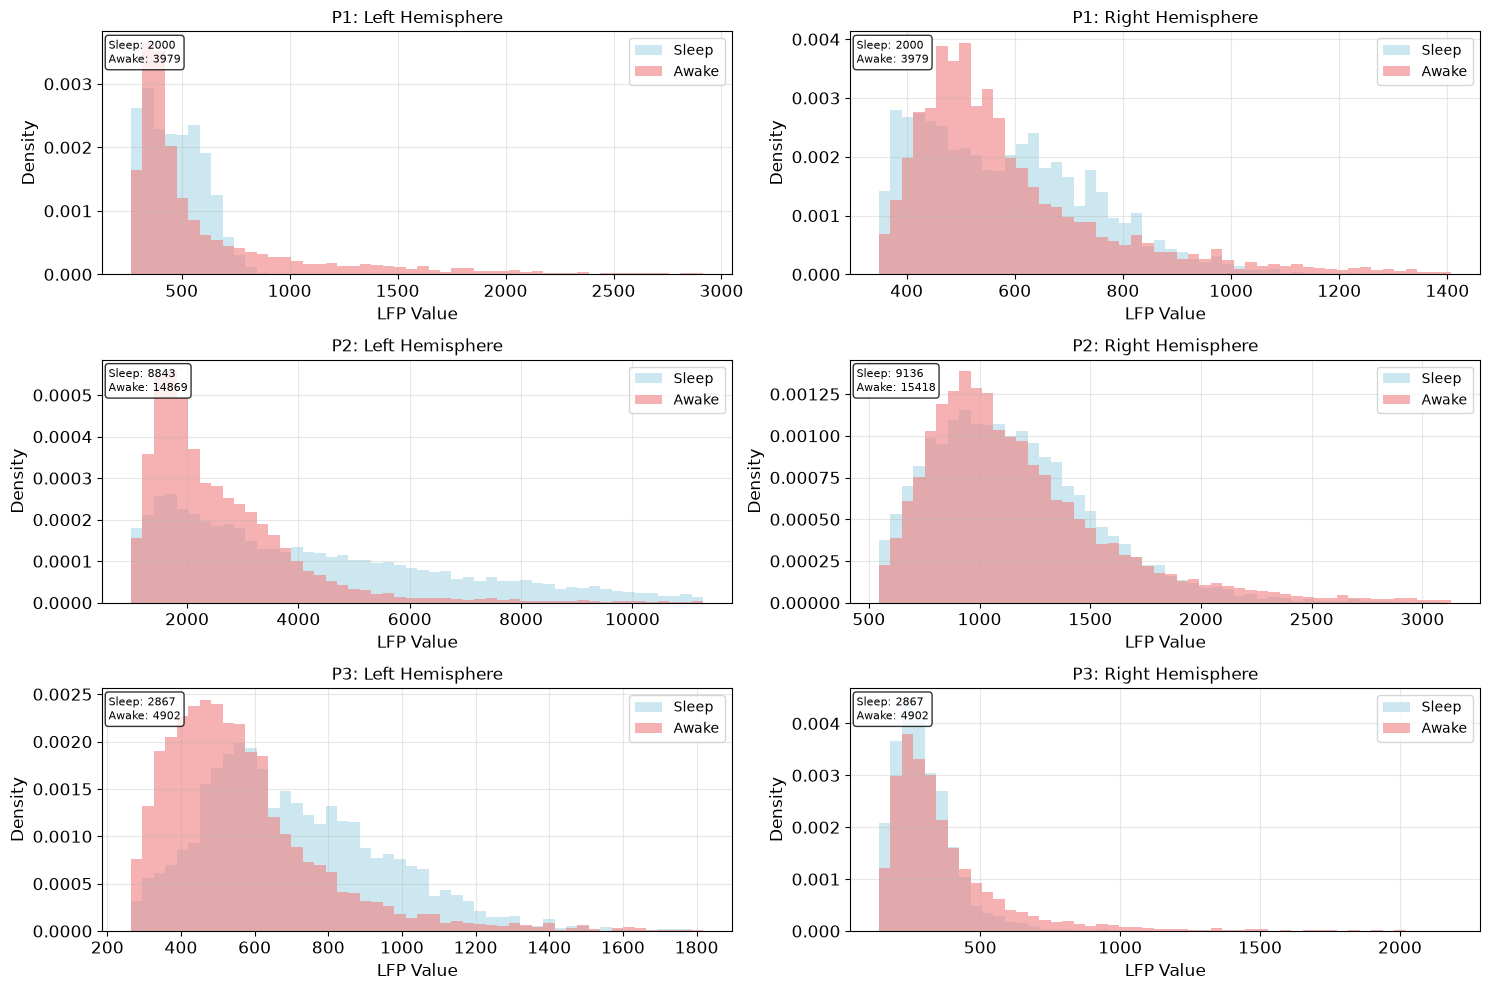

In [58]:
fig, axes = plt.subplots(3, 2, figsize=(15, 10))

for i, (patient, sync_original) in enumerate(sync_data.items()):
    sync = sync_original.copy()

    # only considering neural data when the Oura Ring was simulataneously worn
    worn_mask = sync['ring_worn'].fillna(False).astype(bool)
    data = sync.loc[worn_mask].copy()

    # sleep = stages 1–3; awake = stage 4 + outside sleep (considering brief awake periods during sleep periods as also awake)
    sleep_mask = data['sleep_type'].notna() & data['sleep_phase'].isin([1,2,3])
    awake_mask = ~sleep_mask

    for j, (column, side) in enumerate([('Chronic_LFP_Left', 'Left Hemisphere'), ('Chronic_LFP_Right', 'Right Hemisphere')]):
        ax = axes[i, j]

        # extracting LFP values during sleep & awake states
        sleep_values = pd.to_numeric(data.loc[sleep_mask, column], errors='coerce').dropna()
        awake_values = pd.to_numeric(data.loc[awake_mask, column], errors='coerce').dropna()

        sleep_values = sleep_values[np.isfinite(sleep_values)]
        awake_values = awake_values[np.isfinite(awake_values)]

        # plotting histogram of LFP values during sleep & awake states if valid data points in both states
        if len(sleep_values) > 0 and len(awake_values) > 0:
            all_data = np.concatenate([sleep_values, awake_values])
            q1, q99 = np.percentile(all_data, [1, 99]) # removing extreme outliers for better visualization
            x_range = (q1, q99)

            ax.hist(sleep_values, bins=50, alpha=0.6, label='Sleep', color='lightblue', density=True, range=x_range)
            ax.hist(awake_values, bins=50, alpha=0.6, label='Awake', color='lightcoral', density=True, range=x_range)

            ax.set_title(f'{patient}: {side}')
            ax.set_xlabel('LFP Value', fontsize=12)
            ax.set_ylabel('Density', fontsize=12)
            ax.tick_params(axis='x', labelsize=12)
            ax.tick_params(axis='y', labelsize=12)
            ax.legend()
            ax.grid(True, alpha=0.3)

            ax.text(0.01, 0.97, f'Sleep: {len(sleep_values)}\nAwake: {len(awake_values)}', transform=ax.transAxes,
                    verticalalignment='top', fontsize=8, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        else:
            ax.text(0.01, 0.97, f'No valid data\n(Sleep: {len(sleep_values)}, Awake: {len(awake_values)})',
                    ha='center', va='center', transform=ax.transAxes)

            ax.set_title(f'{patient}: {side} (No Data)')

plt.tight_layout()
plt.savefig('figures/figure3a.svg', format='svg')
plt.show()

#### 3b

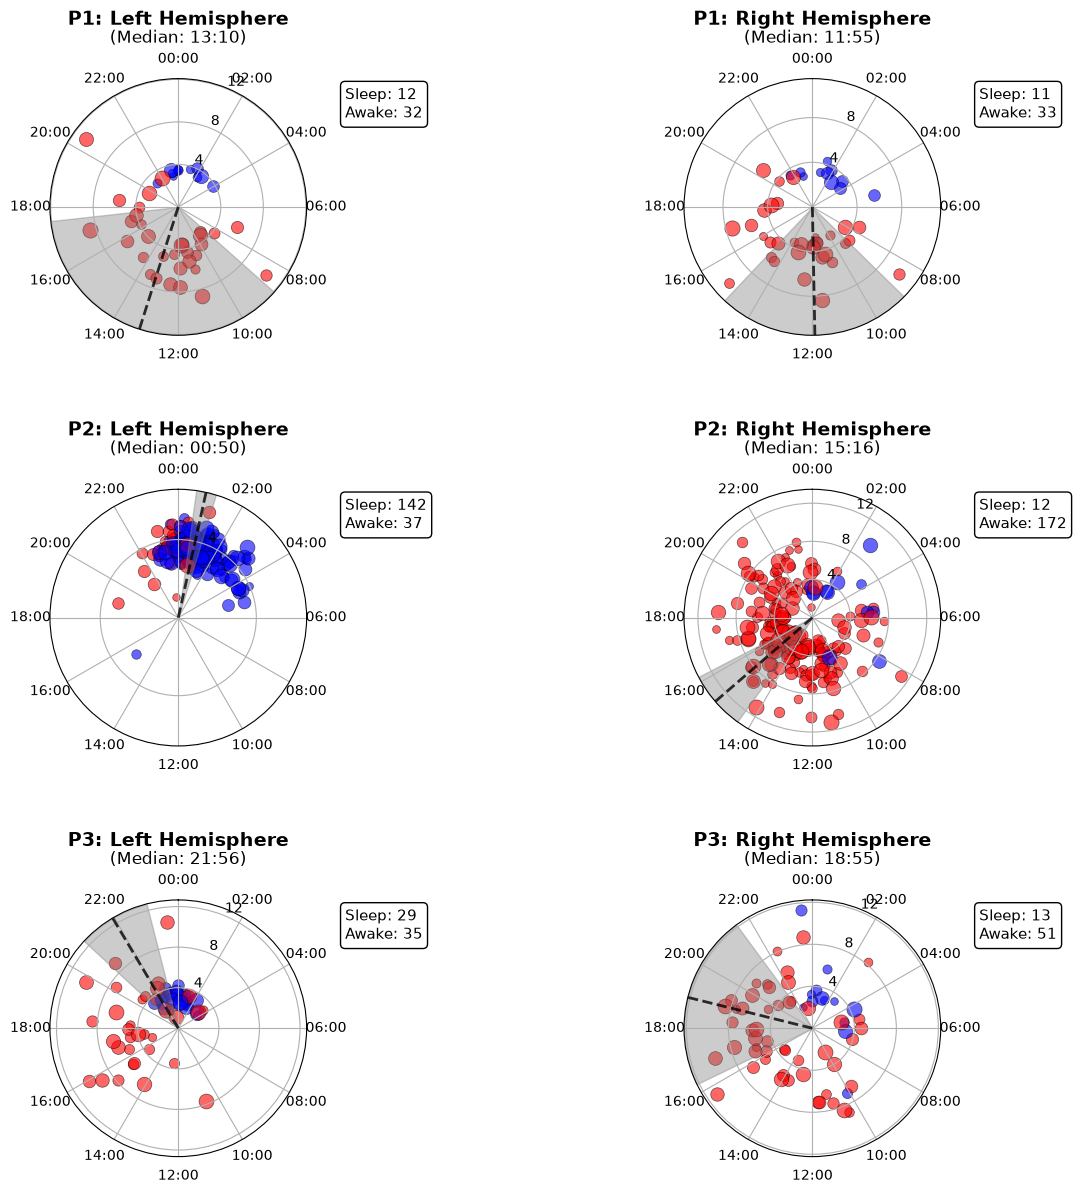

In [61]:
fig, axes = plt.subplots(3, 2, figsize=(15, 14), subplot_kw=dict(projection='polar'))

for i, (patient, sync_original) in enumerate(sync_data.items()):
    sync = sync_original.copy()

    # only considering neural data when the Oura Ring was simultaneously worn
    worn_mask = sync['ring_worn'].fillna(False).astype(bool)
    sync = sync.loc[worn_mask].copy()

    sync['Chronic_LFP_Left'] = pd.to_numeric(sync['Chronic_LFP_Left'], errors='coerce')
    sync['Chronic_LFP_Right'] = pd.to_numeric(sync['Chronic_LFP_Right'], errors='coerce')

    sync.loc[~np.isfinite(sync['Chronic_LFP_Left']), 'Chronic_LFP_Left'] = np.nan
    sync.loc[~np.isfinite(sync['Chronic_LFP_Right']), 'Chronic_LFP_Right'] = np.nan

    # normalizing LFP values within each local calendar day
    sync['Date'] = sync['timestamp_local'].apply(lambda x: x.date() if pd.notna(x) else pd.NaT)

    sync['Left_LFP_Zscore'] = sync.groupby('Date')['Chronic_LFP_Left'].transform(custom_zscore)
    sync['Right_LFP_Zscore'] = sync.groupby('Date')['Chronic_LFP_Right'].transform(custom_zscore)

    # only considering days where a "long sleep" was recorded (i.e., excluding naps, etc.)
    sleep_dates = sync.loc[sync['sleep_type'].eq('long_sleep'), 'Date'].dropna().unique()
    peak_source = sync.loc[sync['Date'].isin(sleep_dates)].copy()

    hemispheres = {
        'left': ('Chronic_LFP_Left', 'Left_LFP_Zscore'),
        'right': ('Chronic_LFP_Right', 'Right_LFP_Zscore')
    }

    for j, (hemisphere, (lfp_column, zscore_column)) in enumerate(hemispheres.items()):
        ax = axes[i, j]

        # keeping only valid LFP observations for peak detection
        peak_data = peak_source.dropna(subset=[lfp_column]).copy()
        peak_data = peak_data.loc[np.isfinite(peak_data[lfp_column])]

        all_peaks_data = []

        if len(peak_data) > 0:
            # identifying the max raw LFP value on each eligible day
            peak_indices = peak_data.groupby('Date')[lfp_column].idxmax()
            daily_peaks = peak_data.loc[peak_indices].sort_index()

            for _, peak_row in daily_peaks.iterrows():
                max_timestamp = peak_row['timestamp_local']
                max_lfp_zscore = peak_row[zscore_column]

                # skipping peaks without valid local time or normalized amplitude
                if pd.isna(max_timestamp) or pd.isna(max_lfp_zscore) or not np.isfinite(float(max_lfp_zscore)):
                    continue

                sleep_phase = peak_row['sleep_phase']

                # classifying each peak as sleep or awake
                if pd.notna(peak_row['sleep_type']) and sleep_phase in [1, 2, 3]:
                    sleep_state = 'sleep'
                else:
                    sleep_state = 'awake'

                # converting local clock time to polar angle
                hour_decimal = max_timestamp.hour + max_timestamp.minute / 60 + max_timestamp.second / 3600
                circular_time = (hour_decimal / 24) * 2*np.pi

                all_peaks_data.append({
                    'time_circular': circular_time,
                    'amplitude': abs(float(max_lfp_zscore)),
                    'timestamp': max_timestamp,
                    'sleep_state': sleep_state
                })

        if all_peaks_data:
            # ordering peaks chronologically so point size increases over time
            all_peaks_data.sort(key=lambda x: x['timestamp'])

            sizes = np.linspace(30, 120, len(all_peaks_data))

            for idx, peak in enumerate(all_peaks_data):
                color = 'blue' if peak['sleep_state'] == 'sleep' else 'red'
                ax.scatter(peak['time_circular'], peak['amplitude'], c=color, s=sizes[idx], alpha=0.6, edgecolors='black', linewidths=0.5)

            sleep_count = sum(p['sleep_state'] == 'sleep' for p in all_peaks_data)
            awake_count = sum(p['sleep_state'] == 'awake' for p in all_peaks_data)

            all_angles = np.array([p['time_circular'] for p in all_peaks_data])
            all_amplitudes = np.array([p['amplitude'] for p in all_peaks_data])

            # calculating circular median peak time
            median_angle = circular_median(all_angles)

            # bootstrapping 95% confidence interval around circular median
            if len(all_angles) >= 3:
                bootstrap_medians = []

                for _ in range(1000):
                    resampled_angles = np.random.choice(all_angles, size=len(all_angles), replace=True)
                    bootstrap_medians.append(circular_median(resampled_angles))

                bootstrap_medians = np.asarray(bootstrap_medians)
                mean_direction = np.angle(np.mean(np.exp(1j * bootstrap_medians)))

                circular_distances = np.minimum(
                    np.abs(bootstrap_medians - mean_direction),
                    2*np.pi - np.abs(bootstrap_medians - mean_direction)
                )

                ci_radius = np.percentile(circular_distances, 97.5)
                ci_lower = (median_angle - ci_radius) % (2*np.pi)
                ci_upper = (median_angle + ci_radius) % (2*np.pi)

            else:
                ci_lower = median_angle
                ci_upper = median_angle

            # setting radial display range from peak z-score amplitudes & shading 95% confidence interval
            plot_radius = np.percentile(all_amplitudes, 95) * 1.4

            if ci_lower != ci_upper:
                if ci_lower <= ci_upper:
                    theta_ci = np.linspace(ci_lower, ci_upper, 100)
                    ax.fill_between(theta_ci, 0, np.full_like(theta_ci, plot_radius), color='gray', alpha=0.4)

                else:
                    theta_ci1 = np.linspace(ci_lower, 2*np.pi, 50)
                    theta_ci2 = np.linspace(0, ci_upper, 50)

                    ax.fill_between(theta_ci1, 0, np.full_like(theta_ci1, plot_radius), color='gray', alpha=0.4)
                    ax.fill_between(theta_ci2, 0, np.full_like(theta_ci2, plot_radius), color='gray', alpha=0.4)

            # plotting circular median peak time
            ax.plot([median_angle, median_angle], [0, plot_radius], 'k--', linewidth=2, alpha=0.8)

            median_hour = median_angle / (2*np.pi) * 24
            median_time_str = f'{int(median_hour):02d}:{int((median_hour % 1) * 60):02d}'

            ax.text(1.15, 0.9, f'Sleep: {sleep_count}\nAwake: {awake_count}', transform=ax.transAxes, fontsize=11,
                    verticalalignment='center', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=1.0))

        else:
            median_time_str = 'N/A'

        ax.set_title('')
        ax.text(0.5, 1.21, f'{patient}: {hemisphere.title()} Hemisphere', transform=ax.transAxes, fontsize=14, fontweight='bold', horizontalalignment='center')
        ax.text(0.5, 1.14, f'(Median: {median_time_str})', transform=ax.transAxes, fontsize=12, horizontalalignment='center')

        ax.set_theta_zero_location('N')
        ax.set_theta_direction(-1)
        ax.set_thetagrids(np.arange(0, 360, 30), ['00:00', '02:00', '04:00', '06:00', '08:00', '10:00',
                                                  '12:00', '14:00', '16:00', '18:00', '20:00', '22:00'])

        if all_peaks_data:
            ax.set_ylim(0, plot_radius)
            ax.set_rticks(range(0, int(plot_radius) + 1, 4))

plt.subplots_adjust(hspace=0.6)
plt.savefig('figures/figure3b.svg', format='svg')
plt.show()

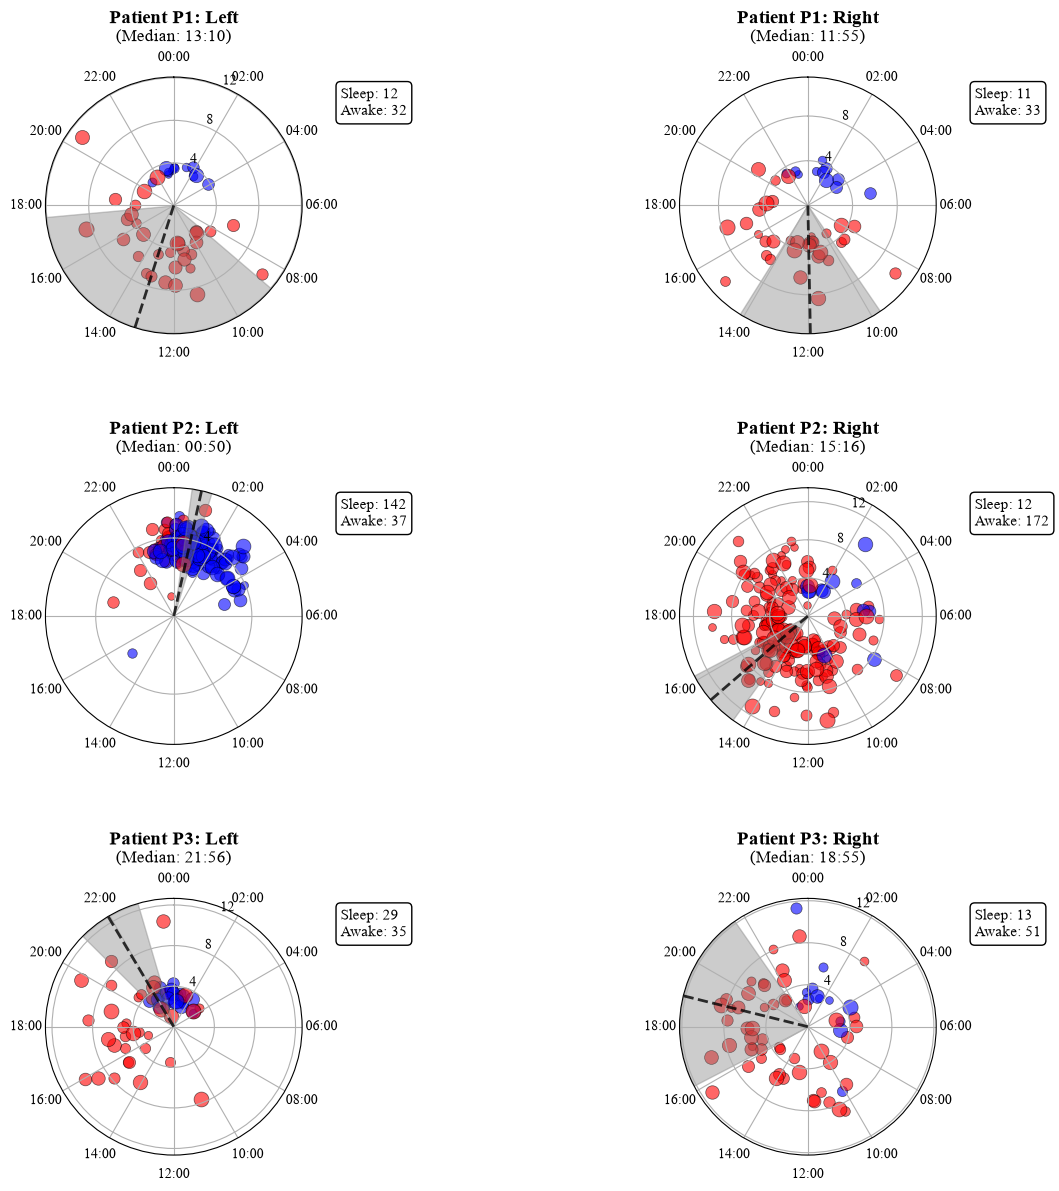

In [93]:
def circular_median(angles):

    angles = np.asarray(angles)

    if len(angles) == 0:
        return np.nan

    test_angles = np.linspace(0, 2 * np.pi, 1440)

    distances = np.abs(test_angles[:, None] - angles[None, :])
    distances = np.minimum(distances, 2 * np.pi - distances)

    return test_angles[np.argmin(distances.sum(axis=1))]


fig, axes = plt.subplots(
    3,
    2,
    figsize=(15, 14),
    subplot_kw=dict(projection='polar')
)

fig.suptitle('', fontsize=16)

for i, (patient_id, sync_original) in enumerate(patients.items()):

    sync = sync_original.copy()

    # only use times where ring was worn
    worn_mask = sync['ring_worn'].fillna(False).astype(bool)
    sync = sync.loc[worn_mask].copy()

    # make LFP columns numeric
    sync['Chronic_LFP_Left'] = pd.to_numeric(
        sync['Chronic_LFP_Left'],
        errors='coerce'
    )

    sync['Chronic_LFP_Right'] = pd.to_numeric(
        sync['Chronic_LFP_Right'],
        errors='coerce'
    )

    # remove infinite values
    sync.loc[
        ~np.isfinite(sync['Chronic_LFP_Left']),
        'Chronic_LFP_Left'
    ] = np.nan

    sync.loc[
        ~np.isfinite(sync['Chronic_LFP_Right']),
        'Chronic_LFP_Right'
    ] = np.nan

    # LOCAL calendar date
    sync['Date'] = sync['timestamp_local'].apply(
        lambda x: x.date() if pd.notna(x) else pd.NaT
    )

    # daily normalization
    def custom_zscore(x):
        result = pd.Series(np.nan, index=x.index)
        valid = x.notna()

        if valid.any():
            result.loc[valid] = zscore(x.loc[valid])

        return result

    sync['Left_LFP_Zscore'] = (
        sync.groupby('Date')['Chronic_LFP_Left'].transform(custom_zscore)
    )

    sync['Right_LFP_Zscore'] = (
        sync.groupby('Date')['Chronic_LFP_Right'].transform(custom_zscore)
    )

    # only consider dates associated with sleep data
    sleep_dates = (
        sync.loc[sync['sleep_type'].eq('long_sleep'), 'Date']
        .dropna()
        .unique()
    )

    peak_source = sync.loc[
        sync['Date'].isin(sleep_dates)
    ].copy()

    hemispheres = {
        'left': ('Chronic_LFP_Left', 'Left_LFP_Zscore'),
        'right': ('Chronic_LFP_Right', 'Right_LFP_Zscore')
    }

    for j, (hemisphere, (lfp_column, zscore_column)) in enumerate(
        hemispheres.items()
    ):

        ax = axes[i, j]

        # valid finite LFP only
        peak_data = peak_source.dropna(
            subset=[lfp_column]
        ).copy()

        peak_data = peak_data.loc[
            np.isfinite(peak_data[lfp_column])
        ]

        all_peaks_data = []

        if len(peak_data) > 0:

            # find maximum raw LFP for each LOCAL day
            peak_indices = (
                peak_data
                .groupby('Date')[lfp_column]
                .idxmax()
            )

            daily_peaks = (
                peak_data
                .loc[peak_indices]
                .sort_index()
            )

            for _, peak_row in daily_peaks.iterrows():

                max_timestamp = peak_row['timestamp_local']
                max_lfp_zscore = peak_row[zscore_column]

                if pd.isna(max_timestamp):
                    continue

                if pd.isna(max_lfp_zscore):
                    continue

                if not np.isfinite(float(max_lfp_zscore)):
                    continue

                sleep_phase = peak_row['sleep_phase']

                if pd.notna(sleep_phase) and sleep_phase != 4:
                    sleep_state = 'sleep'
                else:
                    sleep_state = 'awake'

                # LOCAL clock time
                hour_decimal = (
                    max_timestamp.hour
                    + max_timestamp.minute / 60
                    + max_timestamp.second / 3600
                )

                circular_time = (hour_decimal / 24) * 2 * np.pi

                all_peaks_data.append({
                    'time_circular': circular_time,
                    'amplitude': abs(float(max_lfp_zscore)),
                    'timestamp': max_timestamp,
                    'sleep_state': sleep_state
                })

        if all_peaks_data:

            all_peaks_data.sort(key=lambda x: x['timestamp'])

            n_peaks = len(all_peaks_data)
            sizes = np.linspace(30, 120, n_peaks)

            for idx, peak in enumerate(all_peaks_data):

                color = (
                    'blue'
                    if peak['sleep_state'] == 'sleep'
                    else 'red'
                )

                ax.scatter(
                    peak['time_circular'],
                    peak['amplitude'],
                    c=color,
                    s=sizes[idx],
                    alpha=0.6,
                    edgecolors='black',
                    linewidths=0.5
                )

            sleep_count = sum(
                1 for p in all_peaks_data
                if p['sleep_state'] == 'sleep'
            )

            awake_count = sum(
                1 for p in all_peaks_data
                if p['sleep_state'] == 'awake'
            )

            all_angles = np.array([
                p['time_circular']
                for p in all_peaks_data
            ])

            all_amplitudes = np.array([
                p['amplitude']
                for p in all_peaks_data
            ])

            median_angle = circular_median(all_angles)

            # bootstrap 95% CI
            if len(all_angles) >= 3:

                bootstrap_medians = []

                for _ in range(1000):

                    resampled_angles = np.random.choice(
                        all_angles,
                        size=len(all_angles),
                        replace=True
                    )

                    bootstrap_medians.append(
                        circular_median(resampled_angles)
                    )

                bootstrap_medians = np.asarray(
                    bootstrap_medians
                )

                complex_medians = np.exp(
                    1j * bootstrap_medians
                )

                mean_direction = np.angle(
                    np.mean(complex_medians)
                )

                circular_distances = np.minimum(
                    np.abs(
                        bootstrap_medians
                        - mean_direction
                    ),
                    2 * np.pi
                    - np.abs(
                        bootstrap_medians
                        - mean_direction
                    )
                )

                ci_radius = np.percentile(
                    circular_distances,
                    97.5
                )

                ci_lower = (
                    median_angle
                    - ci_radius
                ) % (2 * np.pi)

                ci_upper = (
                    median_angle
                    + ci_radius
                ) % (2 * np.pi)

            else:
                ci_lower = median_angle
                ci_upper = median_angle

            plot_radius = (
                np.percentile(
                    all_amplitudes,
                    95
                )
                * 1.4
            )

            # plot median 95% confidence interval
            if ci_lower != ci_upper:

                if ci_lower <= ci_upper:

                    theta_ci = np.linspace(
                        ci_lower,
                        ci_upper,
                        100
                    )

                    r_ci = np.full_like(
                        theta_ci,
                        plot_radius
                    )

                    ax.fill_between(
                        theta_ci,
                        0,
                        r_ci,
                        color='gray',
                        alpha=0.4
                    )

                else:

                    theta_ci1 = np.linspace(
                        ci_lower,
                        2 * np.pi,
                        50
                    )

                    theta_ci2 = np.linspace(
                        0,
                        ci_upper,
                        50
                    )

                    r_ci1 = np.full_like(
                        theta_ci1,
                        plot_radius
                    )

                    r_ci2 = np.full_like(
                        theta_ci2,
                        plot_radius
                    )

                    ax.fill_between(
                        theta_ci1,
                        0,
                        r_ci1,
                        color='gray',
                        alpha=0.4
                    )

                    ax.fill_between(
                        theta_ci2,
                        0,
                        r_ci2,
                        color='gray',
                        alpha=0.4
                    )

            # median line
            ax.plot(
                [median_angle, median_angle],
                [0, plot_radius],
                'k--',
                linewidth=2,
                alpha=0.8
            )

            median_hour = (
                median_angle
                / (2 * np.pi)
                * 24
            )

            median_time_str = (
                f'{int(median_hour):02d}:'
                f'{int((median_hour % 1) * 60):02d}'
            )

            ax.text(
                1.15,
                0.9,
                f'Sleep: {sleep_count}\nAwake: {awake_count}',
                transform=ax.transAxes,
                fontsize=11,
                verticalalignment='center',
                bbox=dict(
                    boxstyle='round,pad=0.3',
                    facecolor='white',
                    alpha=1.0
                )
            )

        else:
            median_time_str = 'N/A'

        # original formatting
        ax.set_title('')

        ax.text(
            0.5,
            1.21,
            f'Patient {patient_id}: {hemisphere.title()}',
            transform=ax.transAxes,
            fontsize=14,
            fontweight='bold',
            horizontalalignment='center'
        )

        ax.text(
            0.5,
            1.14,
            f'(Median: {median_time_str})',
            transform=ax.transAxes,
            fontsize=12,
            fontweight='normal',
            horizontalalignment='center'
        )

        ax.set_theta_zero_location('N')
        ax.set_theta_direction(-1)

        ax.set_thetagrids(
            np.arange(0, 360, 30),
            [
                '00:00', '02:00', '04:00', '06:00',
                '08:00', '10:00', '12:00', '14:00',
                '16:00', '18:00', '20:00', '22:00'
            ]
        )

        if all_peaks_data:

            ax.set_ylim(0, plot_radius)

            max_r = int(plot_radius)
            radial_ticks = list(
                range(0, max_r + 1, 4)
            )

            ax.set_rticks(radial_ticks)

plt.subplots_adjust(hspace=0.6)

plt.savefig('figures/figure3b.svg', format='svg')

plt.show()